# Long Call Strategy Backtester (with Full Data & Analytics)

This notebook implements a systematic backtesting framework for evaluating a **Long Call Options Strategy** on SPX index options. It uses a pre-processed dataset of near-month expiry options, enriched with greeks, pricing, and structural information.

### Objectives:
- Load and prepare the SPX options dataset for analysis.
- Identify key trading days in each month such as:
  - First trading day
  - Last trading day
  - Second-to-last trading day
  - Day before expiry
- Create filters based on these trading days to define strategy timing.
- Backtest a long call strategy based on these timing rules.
- Analyze the strategy's returns, win/loss ratio, and performance metrics.

By the end of this notebook, you will have a functional and adaptable backtesting engine to study how entry and exit timing influences long call performance.


## Importing Libraries and Setting Plot Style

We begin by importing essential libraries for data manipulation (`pandas`, `numpy`) and visualization (`matplotlib`). The plot style is set to `seaborn-darkgrid` for better aesthetics in charts.


In [1]:
import pandas as pd
import numpy as np
# For plotting
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('seaborn-darkgrid')

## Loading and Preparing SPX Options Data

We load the pre-processed SPX options dataset (`monthly_spxdata_full.csv`) which contains near-month expiry options.

### Steps:
- Read the CSV file and set the default index to the first column.
- Convert `expire_date` and `quote_date` columns to datetime format.
- Set `quote_date` as the DataFrame index to enable time-based filtering and analysis.

The resulting DataFrame, `options_monthly`, forms the basis for strategy backtesting.


In [2]:
options_monthly = pd.read_csv('monthly_spxdata_full.csv', index_col= 0)
options_monthly['expire_date'] = pd.to_datetime(options_monthly['expire_date'])
options_monthly['quote_date'] = pd.to_datetime(options_monthly['quote_date'])
options_monthly.index = options_monthly['quote_date']
options_monthly

,quote_date,underlying_last,symbol,expire_date,dte,c_delta,c_gamma,c_vega,c_theta,c_rho,...,p_delta,p_gamma,p_vega,p_theta,p_rho,p_iv,p_volume,strike_distance,strike_distance_pct,expiry_type
quote_date,,,,,,,,,,,,,,,,,,,,,
2023-01-04,2023-01-04,3853.39,SPX,2023-01-20,16.0,1.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00112,-0.01021,-0.00006,3.83803,3.0,3653.4,0.948,Near Month
2023-01-04,2023-01-04,3853.39,SPX,2023-01-20,16.0,1.00000,0.00000,0.00000,0.00000,0.00000,...,-0.00016,0.00000,0.00179,-0.00988,-0.00028,2.91754,1.0,3453.4,0.896,Near Month
2023-01-04,2023-01-04,3853.39,SPX,2023-01-20,16.0,1.00000,0.00000,0.00000,0.00000,0.00000,...,-0.00046,0.00000,0.00142,-0.00970,0.00000,2.39189,22.0,3253.4,0.844,Near Month
2023-01-04,2023-01-04,3853.39,SPX,2023-01-20,16.0,1.00000,0.00000,0.00000,0.00000,0.00000,...,-0.00020,0.00000,0.00174,-0.01039,-0.00045,2.02433,116.0,3053.4,0.792,Near Month
2023-01-04,2023-01-04,3853.39,SPX,2023-01-20,16.0,1.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00275,-0.00994,-0.00004,1.74278,1.0,2853.4,0.740,Near Month
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-22,2023-12-22,4755.11,SPX,2023-12-22,0.0,0.00056,0.00002,0.00422,-0.02546,0.00043,...,-0.93834,0.00009,0.23453,-0.50968,-0.02863,1.42827,8.0,594.9,0.125,Near Month
2023-12-22,2023-12-22,4755.11,SPX,2023-12-22,0.0,0.00090,0.00005,0.00353,-0.02537,0.00027,...,-0.93669,0.00007,0.23876,-0.51061,-0.02881,1.54542,NaN,644.9,0.136,Near Month
2023-12-22,2023-12-22,4755.11,SPX,2023-12-22,0.0,0.00066,0.00000,0.00284,-0.02573,-0.00023,...,-0.92922,0.00006,0.25412,-0.51019,-0.02952,2.01438,NaN,844.9,0.178,Near Month


## Identifying Key Trading Days Using Custom Functions

This section defines a set of helper functions to tag each row in the options dataset based on its position within the trading month. These classifications are important because the timing of entry and exit can significantly affect the performance of options strategies, especially for instruments like SPX with standardized monthly expiries.

### Purpose of Multiple Functions:
Options trade on many days within a month, but certain days—like the first trading day or the day before expiry—can be strategically important. These functions help isolate those specific days systematically across all months in the dataset.

### Functions Defined:

1. **`day_before_last(group)`**  
   Returns the second-to-last trading day within a given month. This can be useful for exit timing, especially for avoiding expiry-day risks.

2. **`day_before_expiry(group)`**  
   Identifies the trading day immediately before the option’s expiration date. This helps in setting up exit rules to avoid holding positions on expiry.

3. **`assign_trading_day(date, expire_date)`**  
   This function uses the lists generated from the previous functions (`first_trading_days`, `last_trading_days`, etc.) to label each row in the dataset as:
   - `'first'`
   - `'last'`
   - `'day_before_last'`
   - `'day_before_expiry'`
   - or `'regular'` (if none of the above apply)

These tags allow flexible slicing of the dataset for strategy backtesting, where entry and exit logic may depend on the position of the day in the monthly calendar.


In [3]:
# Get the first trading day for each year-month
first_trading_days = options_monthly.groupby(options_monthly.index.to_period('M')).apply(lambda x: x.index.min())

# Get the last trading day for each year-month
last_trading_days = options_monthly.groupby(options_monthly.index.to_period('M')).apply(lambda x: x.index.max())

# Get the second-to-last trading day for each year-month
def day_before_last(group):
    # Sort the dates by the index and get the second-to-last date
    sorted_dates = group.sort_index()
    if len(sorted_dates) > 1:
        return sorted_dates.index[-2]  # Correct access for second-to-last date
    else:
        return None

day_before_last_trading_days = options_monthly.groupby(options_monthly.index.to_period('M')).apply(day_before_last)

# Get the day before expiry by checking the dates before the expiry
def day_before_expiry(group):
    # Ensure 'expire_date' is in datetime format
    expire_date = pd.to_datetime(group['expire_date'].iloc[0])  # Assuming 'expire_date' is the same for all rows in the group
    
    # Sort the dates by the index
    sorted_dates = group.sort_index()
    
    # Convert the sorted_dates index to datetime if it's not already
    sorted_dates = pd.to_datetime(sorted_dates.index)
    
    # Find the last available date before the expiry date
    day_before_expiry_date = sorted_dates[sorted_dates < expire_date].max()
    
    return day_before_expiry_date if pd.notna(day_before_expiry_date) else None

# Apply the function to get the 'day_before_expiry' for each group
day_before_expiry_trading_days = options_monthly.groupby(options_monthly.index.to_period('M')).apply(day_before_expiry)

# Now, we want to create the 'trading_day' column for the options_monthly DataFrame
def assign_trading_day(date, expire_date):
    if date in first_trading_days.values:
        return 'first'
    elif date in last_trading_days.values:
        return 'last'
    elif date in day_before_last_trading_days.values:
        return 'day_before_last'
    elif date in day_before_expiry_trading_days.values:
        return 'day_before_expiry'
    else:
        return 'regular'

# Apply the function to create the 'trading_day' column
options_monthly['trading_day'] = options_monthly.apply(
    lambda row: assign_trading_day(row.name, row['expire_date']), axis=1)

# To see the result
print(options_monthly[['trading_day']])

           trading_day
quote_date            
2023-01-04       first
2023-01-04       first
2023-01-04       first
2023-01-04       first
2023-01-04       first
...                ...
2023-12-22        last
2023-12-22        last
2023-12-22        last
2023-12-22        last
2023-12-22        last

[51527 rows x 1 columns]


## Creating a Reference Table of Underlying Prices with Trading Day Tags

This section prepares a simplified reference DataFrame that combines the unique underlying SPX index values (`underlying_last`) with their associated trading day tags (e.g., first, last, day_before_expiry). This serves as a clean lookup for strategy signals or for inspection of underlying price movements across key trading dates.

### Steps:
1. **Drop Duplicates**: Removes duplicate values in the `underlying_last` column to retain only one entry per price level (based on index).
2. **Map Trading Day Labels**: Uses a groupby on `quote_date` to get the first observed `trading_day` label for each unique date.
3. **Merge Info**: Creates a new DataFrame where each unique underlying value is associated with its corresponding trading day type.

The resulting `underlying_data` DataFrame provides a clean view of price levels and their contextual position within the trading calendar.


In [4]:
# Drop duplicates in the 'underlying_last' column
underlying_data = options_monthly['underlying_last'].drop_duplicates()

# Create a DataFrame that has 'first_trading_day' for each unique 'quote_date'
trading_day_mapping = options_monthly.groupby(options_monthly.index)['trading_day'].first()

# Map the 'first_trading_day' to 'underlying_data' based on the index
underlying_data = underlying_data.to_frame()  # Convert 'underlying_data' to DataFrame to add a column
underlying_data['trading_day'] = underlying_data.index.map(trading_day_mapping)

# Check the result
print(underlying_data)


            underlying_last        trading_day
quote_date                                    
2023-01-04          3853.39              first
2023-01-05          3808.19            regular
2023-01-06          3894.20            regular
2023-01-09          3892.52            regular
2023-01-10          3919.78            regular
...                     ...                ...
2023-12-18          4740.46            regular
2023-12-19          4768.54            regular
2023-12-20          4698.15            regular
2023-12-21          4747.03  day_before_expiry
2023-12-22          4755.11               last

[175 rows x 2 columns]


## Validating Trading Day Tagging Consistency

We verify whether the number of unique underlying prices tagged as `'first'`, `'last'`, and `'day_before_expiry'` are equal. This check ensures that for each month in the dataset:

- There is exactly one entry corresponding to each of these key trading days.
- The tagging logic applied earlier (using groupby and mapping) worked consistently across months.

If the counts are equal, it implies that every month has been correctly tagged with one and only one `'first'`, `'last'`, and `'day_before_expiry'` trading day in the `underlying_data` DataFrame.


In [5]:
len(underlying_data[underlying_data.trading_day == 'first']) == len(underlying_data[underlying_data.trading_day == 'last']) == len(underlying_data[underlying_data.trading_day == 'day_before_expiry'])

True

## Long Call

## Setting Up Long Call Trade for Backtest

We begin constructing the long call strategy by simulating a single trade entry on a specific analysis date: **January 4, 2023**.

### Steps:
- Filter the full options dataset to extract the option chain available on the selected date.
- Identify the **At-the-Money (ATM) strike price**, defined as the strike with the smallest absolute percentage difference from the underlying.
- Create a `long_call_test` DataFrame that represents a long call position:
  - Option type is set to `'CE'` (Call European-style).
  - The strike price is set to the identified ATM value.
  - A `position` value of `1` indicates a long position.

This object will be used as a building block in the backtest logic to evaluate how the long call performs over time.


In [6]:
# Fetch data for analysis date
analysis_date = "2023-01-04"
 
# Select the options data that corresponds to the date
options_chain_test = options_monthly.loc[analysis_date]

atm_strike_price = options_chain_test[options_chain_test.strike_distance_pct == options_chain_test.strike_distance_pct.min()].strike.values[0]
print(atm_strike_price)

# Create the long_call_test dataframe
long_call_test = pd.DataFrame()

# Set CE as call  
long_call_test['Option Type'] = ['CE']

# Fill the strike price column with the ATM strike price
long_call_test['Strike Price'] = atm_strike_price

# Set the position column to 1
long_call_test['position'] = 1

# Print the long_call_test dataframe
long_call_test


3855.0


,Option Type,Strike Price,position
0,CE,3855.0,1


## Calculating Option Premium for Long Call

To simulate trade execution, we need the **premium** paid to enter the long call position.

### Steps:
- Define the function `get_premium()`:
  - It looks up the traded price (`c_last` for calls or `p_last` for puts) of the option that matches the given strike price.
  - It supports both call (`CE`) and put (`PE`) options, though in this case we're using it for a long call.

- Apply this function row-wise to the `long_call_test` DataFrame using `.apply()`, and store the result in a new `premium` column.

This premium value reflects the cost of entering the long call position on the selected trade date.


In [7]:
# Define the function to get the premium
def get_premium(options_strategy_input, options_data_input):
    
    if options_strategy_input['Option Type'] == 'CE':
        return options_data_input[options_data_input['strike'] == options_strategy_input['Strike Price']].c_last.values[0]
        
    if options_strategy_input['Option Type'] == 'PE':  # Corrected variable name
        return options_data_input[options_data_input['strike'] == options_strategy_input['Strike Price']].p_last.values[0]

# Apply the function to the long_call_test dataframe and store the values on the premium column
long_call_test['premium'] = long_call_test.apply(
    lambda r: get_premium(r, options_chain_test), axis=1)

# Print the updated long_call_test dataframe
long_call_test

,Option Type,Strike Price,position,premium
0,CE,3855.0,1,59.6


## Function: `setup_longcall()`

This function encapsulates the logic for setting up a **long or short call position** on a given analysis date using the corresponding options chain.

### Parameters:
- `analysis_date`: The date of trade initiation.
- `options_chain_data`: A filtered DataFrame of all option contracts available on the `analysis_date`.
- `direction`: Specifies trade direction — `'long'` (default) for buying a call, `'short'` for selling a call.

### Function Logic:
1. Initializes a one-row DataFrame representing the call option.
2. Selects the **ATM strike** — the strike with the smallest absolute % distance from the spot price.
3. Assigns the option type (`CE`), strike, and position (`1` for long or `-1` for short).
4. Looks up the traded premium (entry price) from the options chain using the `get_premium()` helper function.
5. Returns a DataFrame with all necessary fields to simulate or track the trade.

This function makes the backtest modular, allowing you to call it repeatedly for different dates or trade directions with minimal code duplication.


In [8]:
def setup_longcall(analysis_date, options_chain_data, direction = 'long'):
    
    long_call_data = pd.DataFrame()
    long_call_data['Option Type'] = ['CE']
    atm_strike_price = options_chain_data[options_chain_data.strike_distance_pct == options_chain_data.strike_distance_pct.min()].strike.values[0]
    long_call_data['Strike Price'] = atm_strike_price
    long_call_data['position'] = 1

    long_call_data['premium'] = long_call_data.apply(
        lambda r: get_premium(r, options_chain_data), axis=1)

    if direction == 'short':
        long_call_data['position'] *= -1

    long_call_data['premium'] = long_call_data.apply(
        lambda r: get_premium(r, options_chain_data), axis=1)

    return long_call_data

In [9]:
# Get the short long_call strategy dataframe
setup_longcall(analysis_date, options_chain_test, direction='long')

,Option Type,Strike Price,position,premium
0,CE,3855.0,1,59.6


## Backtesting the Long Call Strategy

This section implements a full backtest loop for the Long Call strategy using daily SPX options data and tagged trading days.

### Workflow:

1. **Initialize Structures**  
   Create empty DataFrames:
   - `round_trips_details`: stores complete trade logs
   - `trades`: logs individual trades
   - `mark_to_market`: captures the daily market value of the position

2. **Utility Function – `add_to_mtm()`**  
   Appends the daily MTM value of the strategy to the `mark_to_market` DataFrame for performance tracking.

3. **Initialize Backtest State Variables**  
   - `current_position`: Tracks if a position is open (1) or not (0)
   - `trade_num`: Counter for the number of trades taken
   - `cum_pnl`: Cumulative profit or loss over the backtest
   - `exit_flag`: Signals whether an exit condition has been met

4. **Main Backtest Loop**  
   Iterates over each trading day and performs:

   - **Entry Condition**:  
     If it’s the first trading day of the month and no position is currently open:
     - Set up a long call using `setup_longcall()`
     - Log entry details and initial premium
     - Update MTM and position state

   - **While in Position**:  
     - Update MTM value daily by fetching the current option premium
     - Check for **exit condition**: day before expiry
     - If exit triggered:
       - Record trade details (exit price, PnL, etc.)
       - Append results to `round_trips_details`
       - Update cumulative PnL and reset position state

This structure allows for trade-by-trade simulation and daily valuation, making it easy to track strategy performance over time.


In [10]:
import pandas as pd

# Create dataframes for round trips, storing trades, and mtm
round_trips_details = pd.DataFrame()
trades = pd.DataFrame()
mark_to_market = pd.DataFrame()

# Function for calculating mtm
def add_to_mtm(mark_to_market, option_strategy, trading_date):
    option_strategy['Date'] = trading_date
    mark_to_market = pd.concat([mark_to_market, option_strategy])
    return mark_to_market

# Initialise current position, number of trades and cumulative pnl to 0
current_position = 0
trade_num = 0
cum_pnl = 0

# Set exit flag to False
exit_flag = False

# Set start date for backtesting
start_date = underlying_data.index[0]

for i in underlying_data.loc[start_date:].index:

    if (current_position == 0) & (underlying_data.loc[i, 'trading_day'] == 'first'):
        
        # Setup long call
        options_data_daily = options_monthly.loc[i]
        long_call_strategy = setup_longcall(i, options_data_daily, direction="long")
        
        # Populate the trades dataframe
        trades = long_call_strategy.copy()
        trades['entry_date'] = i
        trades.rename(columns={'premium': 'entry_price'}, inplace=True)            

        # Calculate net premium 
        net_premium = round((long_call_strategy.position * long_call_strategy.premium).sum(), 1)

        # Update current position to 1
        current_position = 1

        # Update mark_to_market dataframe
        mark_to_market = add_to_mtm(mark_to_market, long_call_strategy, i)

        # Increase number of trades by 1
        trade_num += 1   

        # Print formatted entry log
        print(f"\n━━━━ Trade No: {trade_num} ━━━━")
        print(f"  Entry:  ")
        print(f"    → Date: {i}  ")
        print(f"    → Premium Paid: {net_premium}  ")

    elif current_position == 1:
        
        # Update net premium
        options_data_daily = options_monthly.loc[i]
        long_call_strategy['premium'] = long_call_strategy.apply(lambda r: get_premium(r, options_data_daily), axis=1)
        net_premium = (long_call_strategy.position * long_call_strategy.premium).sum()

        # Update mark_to_market dataframe
        mark_to_market = add_to_mtm(mark_to_market, long_call_strategy, i)
        
        # Exit at expiry
        if underlying_data.loc[i, 'trading_day'] == 'day_before_expiry':
            exit_type = 'Expiry'
            exit_flag = True    

        if exit_flag:
            # Update the trades dataframe
            trades['exit_date'] = i
            trades['exit_type'] = exit_type
            trades['exit_price'] = long_call_strategy.premium

            # Add the trade logs to round trip details
            round_trips_details = pd.concat([round_trips_details, trades])

            # Calculate net premium at exit
            net_premium = round((long_call_strategy.position * long_call_strategy.premium).sum(), 1)   

            # Calculate net premium on entry
            entry_net_premium = (trades.position * trades.entry_price).sum()       

            # Calculate pnl for the trade
            trade_pnl = round(net_premium - entry_net_premium, 1)

            # Calculate cumulative pnl
            cum_pnl += trade_pnl
            cum_pnl = round(cum_pnl, 2)

            # Print formatted exit log
            print(f"\n  Exit:  ")
            print(f"    → Type: {exit_type}  ")
            print(f"    → Date: {i}  ")
            print(f"    → Premium Received: {net_premium}  ")
            print(f"    → Profit/Loss: {trade_pnl}  ")
            print(f"    → Cumulative PnL: {cum_pnl}  ")

            # Update current position to 0
            current_position = 0    

            # Update mark_to_market dataframe
            mark_to_market = add_to_mtm(mark_to_market, long_call_strategy, i)

            # Set exit flag to false
            exit_flag = False



━━━━ Trade No: 1 ━━━━
  Entry:  
    → Date: 2023-01-04 00:00:00  
    → Premium Paid: 59.6  

  Exit:  
    → Type: Expiry  
    → Date: 2023-01-19 00:00:00  
    → Premium Received: 58.9  
    → Profit/Loss: -0.7  
    → Cumulative PnL: -0.7  

━━━━ Trade No: 2 ━━━━
  Entry:  
    → Date: 2023-02-01 00:00:00  
    → Premium Paid: 64.3  

  Exit:  
    → Type: Expiry  
    → Date: 2023-02-16 00:00:00  
    → Premium Received: 2.3  
    → Profit/Loss: -62.0  
    → Cumulative PnL: -62.7  

━━━━ Trade No: 3 ━━━━
  Entry:  
    → Date: 2023-03-01 00:00:00  
    → Premium Paid: 83.5  

  Exit:  
    → Type: Expiry  
    → Date: 2023-03-23 00:00:00  
    → Premium Received: 24.1  
    → Profit/Loss: -59.4  
    → Cumulative PnL: -122.1  

━━━━ Trade No: 4 ━━━━
  Entry:  
    → Date: 2023-04-03 00:00:00  
    → Premium Paid: 59.5  

  Exit:  
    → Type: Expiry  
    → Date: 2023-04-20 00:00:00  
    → Premium Received: 8.2  
    → Profit/Loss: -51.3  
    → Cumulative PnL: -173.4  

━━━━ 

## Viewing Round Trip Trade Details

The `round_trips_details` DataFrame contains a complete log of all executed trades during the backtest.

Each row records:
- Entry and exit dates
- Option type and strike
- Entry and exit premiums
- Exit reason (e.g., expiry)
- Calculated profit or loss for each trade

This table forms the basis for analyzing the strategy’s performance and trade-by-trade behavior.


In [11]:
# Round trip details
round_trips_details

,Option Type,Strike Price,position,entry_price,entry_date,exit_date,exit_type,exit_price
0,CE,3855.0,1,59.60,2023-01-04,2023-01-19,Expiry,58.86
0,CE,4120.0,1,64.30,2023-02-01,2023-02-16,Expiry,2.31
0,CE,3950.0,1,83.50,2023-03-01,2023-03-23,Expiry,24.06
0,CE,4125.0,1,59.52,2023-04-03,2023-04-20,Expiry,8.18
0,CE,4165.0,1,55.30,2023-05-01,2023-05-18,Expiry,35.07
0,CE,4220.0,1,56.40,2023-06-01,2023-06-22,Expiry,176.16
0,CE,4455.0,1,44.33,2023-07-03,2023-07-20,Expiry,96.55
0,CE,4575.0,1,49.60,2023-08-01,2023-08-17,Expiry,0.10
0,CE,4515.0,1,50.71,2023-09-01,2023-09-21,Expiry,0.07
0,CE,4290.0,1,55.67,2023-10-02,2023-10-19,Expiry,7.90


## Generating the Trade Sheet with PnL and Costs

In this section, we compile a clean and summarized **trade sheet** from the round trip data. Each row represents one completed trade, along with performance and cost metrics.

### Key Steps:
- **Assumed Lot Size**: Each options trade is scaled to 50 units (lot size of 50).
- **Trade-wise PnL**: Calculated as `(exit price - entry price) × position`.
- **Grouping**: Trades are grouped by `entry_date` to consolidate round trips with the same entry.
- **Turnover**: Approximated as the sum of entry and exit premiums multiplied by the lot size.
- **Trading Costs and Slippages**: Deducted as 1% of turnover to simulate realistic trading conditions.
- **Final Output**: A clean `trades` DataFrame showing:
  - Entry and exit dates
  - Exit type (e.g., expiry)
  - PnL before and after costs
  - Turnover for each trade

This trade sheet is useful for performance analytics and helps in generating summary statistics like win rate, average return, and drawdowns.


In [12]:
# Assume lot size as 50
lot_size = 50

round_trips = round_trips_details.copy()

# Calculate net premium 
round_trips['trade_wise_PnL'] = round_trips['position'] * (round_trips['exit_price'] - round_trips['entry_price'])

# Create a dataframe for storing trades
trades = pd.DataFrame()

# Groupby entry date
trades_group = round_trips.groupby('entry_date')

# Group trades from round_trips
trades['entry_date'] = trades_group['entry_date'].first()
trades['exit_date'] = trades_group['exit_date'].first()
trades['exit_type'] = trades_group['exit_type'].first()

# Calculate PnL for the strategy for 1 lot
trades['pnl'] = trades_group.trade_wise_PnL.sum() * lot_size

# Calculate turnover for trades
trades['turnover'] = (trades_group['exit_price'].sum() + trades_group['entry_price'].sum()) * lot_size

# Calculate PnL after deducting trading costs and slippages
trades['pnl_post_trading_costs_slippages'] = trades['pnl'] - trades['turnover']*(0.01)

# Reset index
trades.reset_index(drop = True, inplace = True)
trades

,entry_date,exit_date,exit_type,pnl,turnover,pnl_post_trading_costs_slippages
0,2023-01-04,2023-01-19,Expiry,-37.0,5923.0,-96.230
1,2023-02-01,2023-02-16,Expiry,-3099.5,3330.5,-3132.805
2,2023-03-01,2023-03-23,Expiry,-2972.0,5378.0,-3025.780
3,2023-04-03,2023-04-20,Expiry,-2567.0,3385.0,-2600.850
4,2023-05-01,2023-05-18,Expiry,-1011.5,4518.5,-1056.685
5,2023-06-01,2023-06-22,Expiry,5988.0,11628.0,5871.720
6,2023-07-03,2023-07-20,Expiry,2611.0,7044.0,2540.560
7,2023-08-01,2023-08-17,Expiry,-2475.0,2485.0,-2499.850
8,2023-09-01,2023-09-21,Expiry,-2532.0,2539.0,-2557.390
9,2023-10-02,2023-10-19,Expiry,-2388.5,3178.5,-2420.285


## Visualizing Entry and Exit Points on Underlying Price

This chart overlays the long call strategy’s entry and exit signals on the SPX underlying price chart.

### Purpose:
To visually confirm that positions are entered on the **first trading day** of each month and exited on the **day before expiry**, aligned with strategy logic.

### Plot Details:
- **Blue Line (Left Y-Axis)**: Shows the daily SPX index price (`underlying_last`).
- **Green Step Line (Right Y-Axis)**: Shows the strategy's position:
  - `1` indicates an active long call position
  - `0` indicates no open position

### Steps:
1. Create a binary `position` column based on trade entry and exit dates.
2. Forward-fill the `position` values to reflect when trades remain open.
3. Plot the underlying price and position on a dual-axis chart for clarity.

This plot provides a visual audit trail of trade execution and holding periods in relation to market movements.


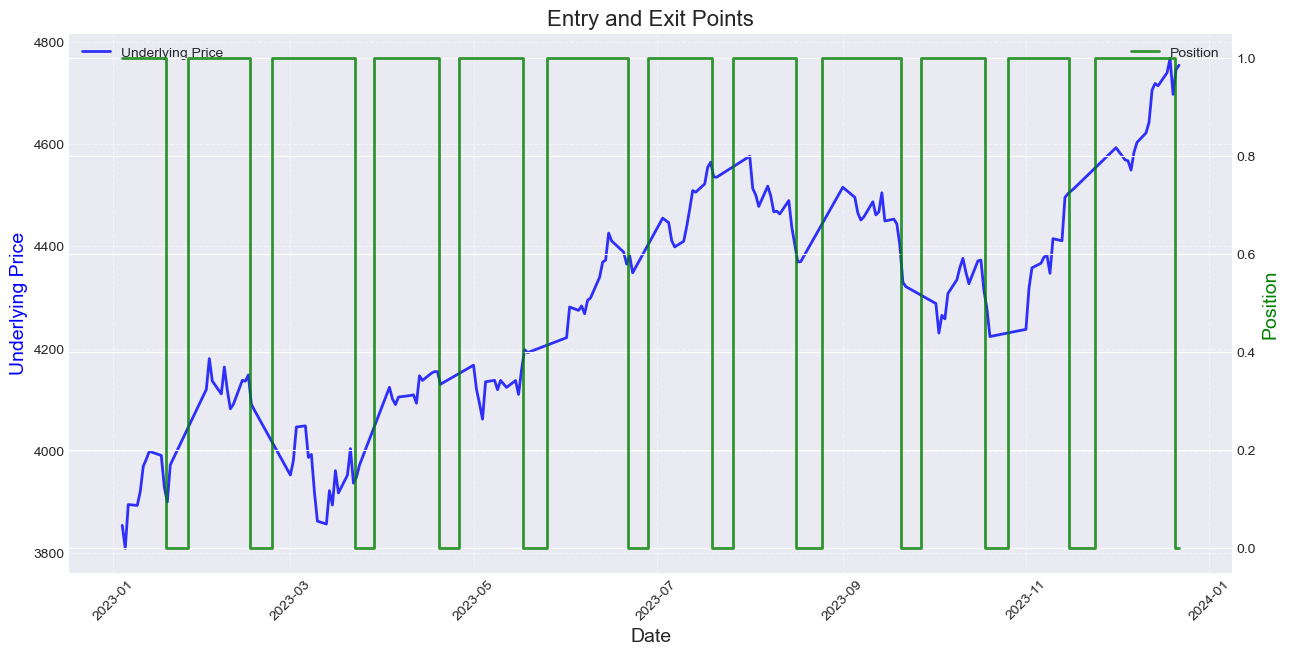

In [13]:
# Copy the data
underlying_daily_data = underlying_data.copy()

# Track entry and exit positions
underlying_daily_data['position'] = np.nan
underlying_daily_data.loc[underlying_daily_data.index.isin(trades['entry_date']), 'position'] = 1
underlying_daily_data.loc[underlying_daily_data.index.isin(trades['exit_date']), 'position'] = 0

# Forward-fill missing values in the position column
underlying_daily_data['position'].fillna(method='ffill', inplace=True)

# Select data from the first trade entry date
data_for_plot = underlying_daily_data.loc[trades.entry_date.iloc[0]:]

# Create figure
fig, ax1 = plt.subplots(figsize=(15, 7))

# Plot underlying price
ax1.plot(data_for_plot.index, data_for_plot['underlying_last'], 
         color='blue', linewidth=2, alpha=0.8, label="Underlying Price")

# Set primary y-axis label
ax1.set_ylabel('Underlying Price', fontsize=14, color='blue')
ax1.set_xlabel('Date', fontsize=14)

# Create secondary y-axis for position tracking
ax2 = ax1.twinx()
ax2.step(data_for_plot.index, data_for_plot['position'], 
         where='mid', color='green', linewidth=2, alpha=0.8, linestyle='-', label="Position")

# Set secondary y-axis label
ax2.set_ylabel('Position', fontsize=14, color='green')

# Formatting
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.set_title('Entry and Exit Points', fontsize=16)
ax1.tick_params(axis='x', labelrotation=45)

# Legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Show plot
plt.show()


# Performance Metrics for Backtesting

## Displaying Trading Performance Summary

This section prints a clean and readable summary of the strategy's backtest performance using standard financial metrics.

### What It Shows:

### Overall Performance
- **Total PnL**: Net profit/loss across all trades after accounting for costs.
- **Total Trades**: Number of round-trip trades executed.

### Win/Loss Breakdown
- **Winning Trades** and **Losing Trades**: Absolute counts.
- **Win % / Loss %**: Proportion of trades that ended in profit or loss.

### Trade Profitability
- **Average Profit (Winners)**: Mean gain from profitable trades.
- **Average Loss (Losers)**: Mean loss from unprofitable trades.
- **Profit Factor**: Ratio of gross gains to gross losses, adjusted for frequency. This is a core risk-reward metric.

### Trade Duration
- **Average Holding Time**: Average time (in days) that each position remained open.

This block is useful for terminal display or logs and helps summarize backtest performance in a human-readable way—ideal for validation or reporting.


In [14]:
# Extract analytics data
Total_PnL = trades['pnl_post_trading_costs_slippages'].sum()
Total_Trades = len(trades)
Winners = len(trades.loc[trades.pnl >= 0])
Losers = len(trades.loc[trades.pnl < 0])
Win_Percentage = 100 * (Winners / Total_Trades) if Total_Trades > 0 else 0
Loss_Percentage = 100 * (Losers / Total_Trades) if Total_Trades > 0 else 0
per_trade_profit_winners = trades.loc[trades.pnl > 0].pnl.mean() or 0
per_trade_loss_losers = abs(trades.loc[trades.pnl < 0].pnl.mean() or 0)

# Calculate holding period
trades['entry_date'] = pd.to_datetime(trades['entry_date'])
trades['exit_date'] = pd.to_datetime(trades['exit_date'])
trades['holding_period'] = (trades['exit_date'] - trades['entry_date']).dt.days
Average_holding_time = trades['holding_period'].mean() or 0

# Calculate profit factor
Profit_Factor = (
    (Win_Percentage * per_trade_profit_winners) / 
    (Loss_Percentage * per_trade_loss_losers) 
    if Loss_Percentage * per_trade_loss_losers > 0 else None
)

# Print results in formatted style
print("\n" + "="*40)
print("       Trading Performance Summary      ")
print("="*40)

print("\nOverall Performance")
print(f"- Total PnL: ${Total_PnL:,.2f}")
print(f"- Total Trades: {Total_Trades}")

print("\nWin/Loss Breakdown")
print(f"- Winning Trades: {Winners}")
print(f"- Losing Trades: {Losers}")
print(f"- Win Percentage: {Win_Percentage:.2f}%")
print(f"- Loss Percentage: {Loss_Percentage:.2f}%")

print("\nTrade Profitability")
print(f"- Avg Profit per Winning Trade: ${per_trade_profit_winners:,.2f}")
print(f"- Avg Loss per Losing Trade: ${per_trade_loss_losers:,.2f}")
print(f"- Profit Factor: {Profit_Factor:.2f}" if Profit_Factor else "- Profit Factor: N/A")

print("\nTrade Duration")
print(f"- Average Holding Time: {Average_holding_time:.0f} days")

print("="*40)



       Trading Performance Summary      

Overall Performance
- Total PnL: $5,463.14
- Total Trades: 12

Win/Loss Breakdown
- Winning Trades: 4
- Losing Trades: 8
- Win Percentage: 33.33%
- Loss Percentage: 66.67%

Trade Profitability
- Avg Profit per Winning Trade: $5,821.38
- Avg Loss per Losing Trade: $2,135.31
- Profit Factor: 1.36

Trade Duration
- Average Holding Time: 18 days


## Strategy Analytics

### Calculating Margin and Capital Requirement

This section calculates the capital or margin required on each day of the backtest based on whether the strategy holds a **long call** or, hypothetically, a **short position** (though only long calls are used in this case).

### Key Components:

- **Lot Size**: Assumed to be 50 units per option contract.
- **Net Premium**: Daily mark-to-market value calculated as `position × premium × lot size`.
- **Capital for Long Options**: When buying options, capital required is simply the premium paid multiplied by lot size.
- **Margin for Short Options (Hypothetical)**:
  - **SPAN Margin**: 10% of notional value.
  - **Exposure Margin**: 6% of notional value.
  - **Extra Cushion**: 3% of notional value added as a buffer.
  - **Total Margin** = SPAN + Exposure + Additional 3%.

The result is stored in the `margin` column and differentiates between capital needs for long vs. short positions. Although this strategy uses only long calls, the structure supports both directions.


In [15]:
# Assume lot size as 50
lot_size = 50
mtm = mark_to_market.copy()
# Calculate net premium
mtm['net_premium'] = mtm.position * mtm.premium * lot_size

# Initialise a column to store margin
mtm["margin"] = np.nan

# Capital required for option buying
capital_option_buying = mtm['premium'] * lot_size

# Notional value
notional_value = mtm['Strike Price'] * lot_size

# Span margin for shorting option
span = (notional_value * 0.1)

# Exposure margin for shorting option
exposure = (notional_value * 0.06)

# Adding 5% of notional value to the margin
margin_option_selling = span + exposure + (0.03 * notional_value)

# Calculate capital required for buy positions
mtm["margin"] = np.where(mtm['position'] == 1,
                         capital_option_buying, mtm['margin'])

# Calculate margin required for sell positions
mtm["margin"] = np.where(mtm['position'] == -1,
                         margin_option_selling, mtm['margin'])
mtm

,Option Type,Strike Price,position,premium,Date,net_premium,margin
0,CE,3855.0,1,59.60,2023-01-04,2980.0,2980.0
0,CE,3855.0,1,48.90,2023-01-05,2445.0,2445.0
0,CE,3855.0,1,85.25,2023-01-06,4262.5,4262.5
0,CE,3855.0,1,85.25,2023-01-09,4262.5,4262.5
0,CE,3855.0,1,81.55,2023-01-10,4077.5,4077.5
...,...,...,...,...,...,...,...
0,CE,4595.0,1,147.07,2023-12-18,7353.5,7353.5
0,CE,4595.0,1,170.73,2023-12-19,8536.5,8536.5
0,CE,4595.0,1,125.50,2023-12-20,6275.0,6275.0
0,CE,4595.0,1,127.50,2023-12-21,6375.0,6375.0


## Calculating Daily PnL and Returns

This section computes the daily profit and loss (PnL) and return on capital deployed for the long call strategy.

### Key Steps:

- **Daily PnL**:
  - Aggregated by date using the net premium (`position × premium × lot size`).
  - The change in this value from one day to the next gives the daily PnL.
  - PnL is explicitly set to zero on trade entry dates to avoid artificial spikes.

- **Daily Margin**:
  - Margin is summed for all active positions on each date.
  - A 70% netting benefit is assumed, reducing the effective capital usage to 30% of total margin.

- **Daily Returns**:
  - Computed as `PnL / Adjusted Margin` to evaluate capital efficiency.

This daily view is essential for analyzing risk-adjusted performance, tracking drawdowns, and computing metrics such as Sharpe or Sortino ratios.


In [16]:
# Step 1: Calculate daily PnL (already includes lot size)
analytics = pd.DataFrame()
analytics['PnL'] = mtm.groupby('Date').net_premium.sum().diff()

# Set PnL to 0 on entry days to avoid jump due to premium payment
analytics.loc[analytics.index.isin(round_trips.entry_date), 'PnL'] = 0

# Step 2: Calculate daily margin used
daily_mtm = pd.DataFrame()
daily_mtm["margin"] = mtm.groupby('Date').margin.sum()
daily_mtm["margin"] *= 0.3  # Apply netting benefit

# Step 3: Compute daily returns as % return
daily_mtm["daily_returns"] = analytics['PnL'] / daily_mtm["margin"]

daily_mtm

,margin,daily_returns
Date,,
2023-01-04,894.00,0.000000
2023-01-05,733.50,-0.729380
2023-01-06,1278.75,1.421310
2023-01-09,1278.75,0.000000
2023-01-10,1223.25,-0.151236
...,...,...
2023-12-15,906.75,0.000000
2023-12-18,2206.05,1.963237
2023-12-19,2560.95,0.461938


## Tracking and Plotting Cumulative Strategy Returns

This section calculates the cumulative returns of the long call strategy over time, allowing us to evaluate its growth trajectory.

### Key Steps:

- **Assign Daily Returns**:
  - The `daily_returns` from the earlier margin-based return calculation are merged into the `underlying_daily_data` dataframe by date.

- **Fill Missing Values**:
  - Any dates without returns (e.g., weekends, holidays) are filled with `0` to ensure continuity in cumulative calculations.

- **Cumulative Returns**:
  - The strategy’s growth curve is computed using a rolling product of daily returns:  
    `(1 + daily_return).cumprod()`

This resulting `Cumulative_Returns` column reflects how an initial investment would grow if fully reinvested in the strategy each day, helping to visualize performance over time.


In [17]:
# Initialise a column to track returns
underlying_daily_data['strategy_returns'] = np.nan
underlying_daily_data

,underlying_last,trading_day,position,strategy_returns
quote_date,,,,
2023-01-04,3853.39,first,1.0,NaN
2023-01-05,3808.19,regular,1.0,NaN
2023-01-06,3894.20,regular,1.0,NaN
2023-01-09,3892.52,regular,1.0,NaN
2023-01-10,3919.78,regular,1.0,NaN
...,...,...,...,...
2023-12-18,4740.46,regular,1.0,NaN
2023-12-19,4768.54,regular,1.0,NaN
2023-12-20,4698.15,regular,1.0,NaN


In [18]:
# Efficient update of strategy returns if indices match
underlying_daily_data.loc[daily_mtm.index, 'strategy_returns'] = daily_mtm['daily_returns']

# Fill missing strategy returns with 0
underlying_daily_data["strategy_returns"].fillna(0, inplace=True)

# Step 6: Track capital and cumulative returns
initial_capital = 100000  # or any capital base you prefer

# Equity curve by accumulating daily PnL
underlying_daily_data['equity_curve'] = initial_capital + (underlying_daily_data['strategy_returns'] * daily_mtm["margin"]).fillna(0).cumsum()

# Cumulative return from equity growth
underlying_daily_data['cumulative_returns'] = (underlying_daily_data['equity_curve'] / initial_capital) - 1

# Step 7: Inspect result
print(underlying_daily_data[['strategy_returns', 'equity_curve', 'cumulative_returns']].tail())

            strategy_returns  equity_curve  cumulative_returns
quote_date                                                    
2023-12-18          1.963237      140901.0            0.409010
2023-12-19          0.461938      142084.0            0.420840
2023-12-20         -1.201328      139822.5            0.398225
2023-12-21          1.692810      146297.5            0.462975
2023-12-22          0.000000      146297.5            0.462975


## Plotting Cumulative Returns vs Underlying Price with Trade Markers

This chart provides a visual comparison between the strategy’s performance and the underlying asset’s price, annotated with trade entry and exit points.

### Key Elements:

- **Left Y-Axis (Blue)**:
  - Plots the `underlying_last` price over time to show the market trend.

- **Right Y-Axis (Red)**:
  - Displays the strategy's `cumulative_returns`, illustrating how returns compound over time.

- **Trade Markers**:
  - Green upward arrows (▲) indicate trade **entries**.
  - Black downward arrows (▼) indicate trade **exits**.

This visualization helps assess how well the strategy aligns with the underlying market moves and whether entries/exits are well-timed relative to price movements.


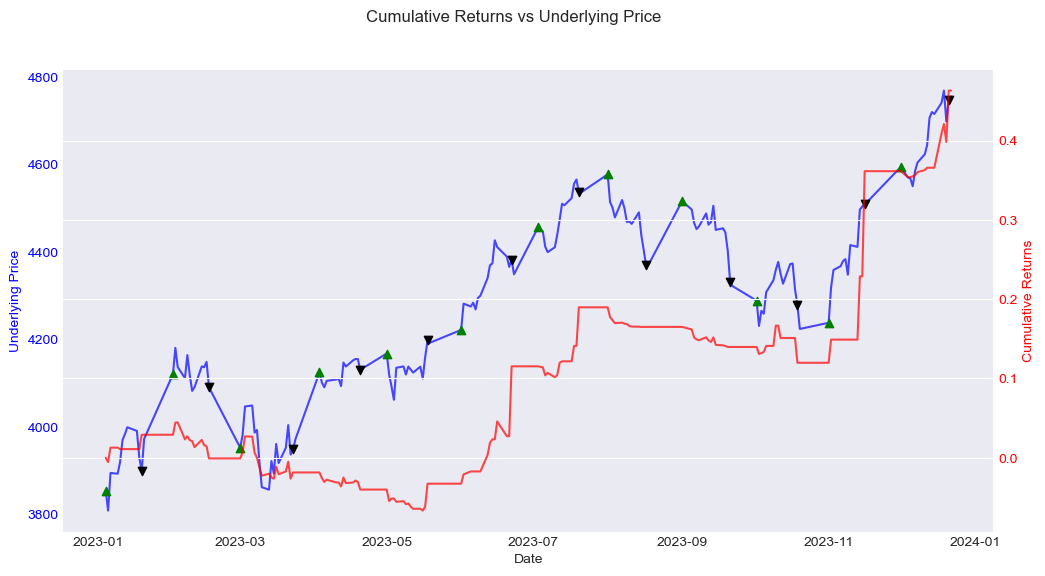

In [19]:
# Create figure and axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot underlying price on left y-axis
ax1.set_xlabel("Date")
ax1.set_ylabel("Underlying Price", color="blue")
ax1.plot(underlying_daily_data.index, underlying_daily_data["underlying_last"], label="Underlying Price", color="blue", alpha=0.7)
ax1.tick_params(axis="y", labelcolor="blue")

# Create second y-axis for cumulative returns
ax2 = ax1.twinx()
ax2.set_ylabel("Cumulative Returns", color="red")
ax2.plot(underlying_daily_data.index, underlying_daily_data["cumulative_returns"], label="Cumulative Returns", color="red", alpha=0.7)
ax2.tick_params(axis="y", labelcolor="red")

# Mark trade entry and exit points on the underlying price chart
ax1.scatter(trades["entry_date"], [underlying_daily_data.loc[d, "underlying_last"] for d in trades["entry_date"]], 
            color="green", marker="^", label="Entry", zorder=3)
ax1.scatter(trades["exit_date"], [underlying_daily_data.loc[d, "underlying_last"] for d in trades["exit_date"]], 
            color="black", marker="v", label="Exit", zorder=3)

# Add grid and legend
ax1.grid()
fig.suptitle("Cumulative Returns vs Underlying Price")

# Show the plot
plt.show()


### Monthly Strategy Return Heatmap

In this section, we visualize the monthly performance of the strategy using a heatmap.

- **Objective**: Summarize strategy returns month-wise over time.
- **Process**:
  - Daily returns are compounded to calculate monthly returns.
  - A pivot table is created with years as rows and months as columns.
- **Visualization**:
  - A heatmap is plotted using shades of green for gains and red for losses.
  - Darker colors represent more extreme values.

This heatmap helps identify patterns, seasonality, and consistency in strategy performance across months and years.


✅ Heatmap Pivot Table:
 Month  January    February       March      April          May         June  \
Year                                                                          
2023   12.5763  277.580759 -152.678797 -99.972956  5319.419522  1258.888247   

Month          July      August  September      October     November  \
Year                                                                   
2023   14738.729238 -459.212176 -130.91087 -1526.413567  2181.410816   

Month   December  
Year              
2023   208.07476  


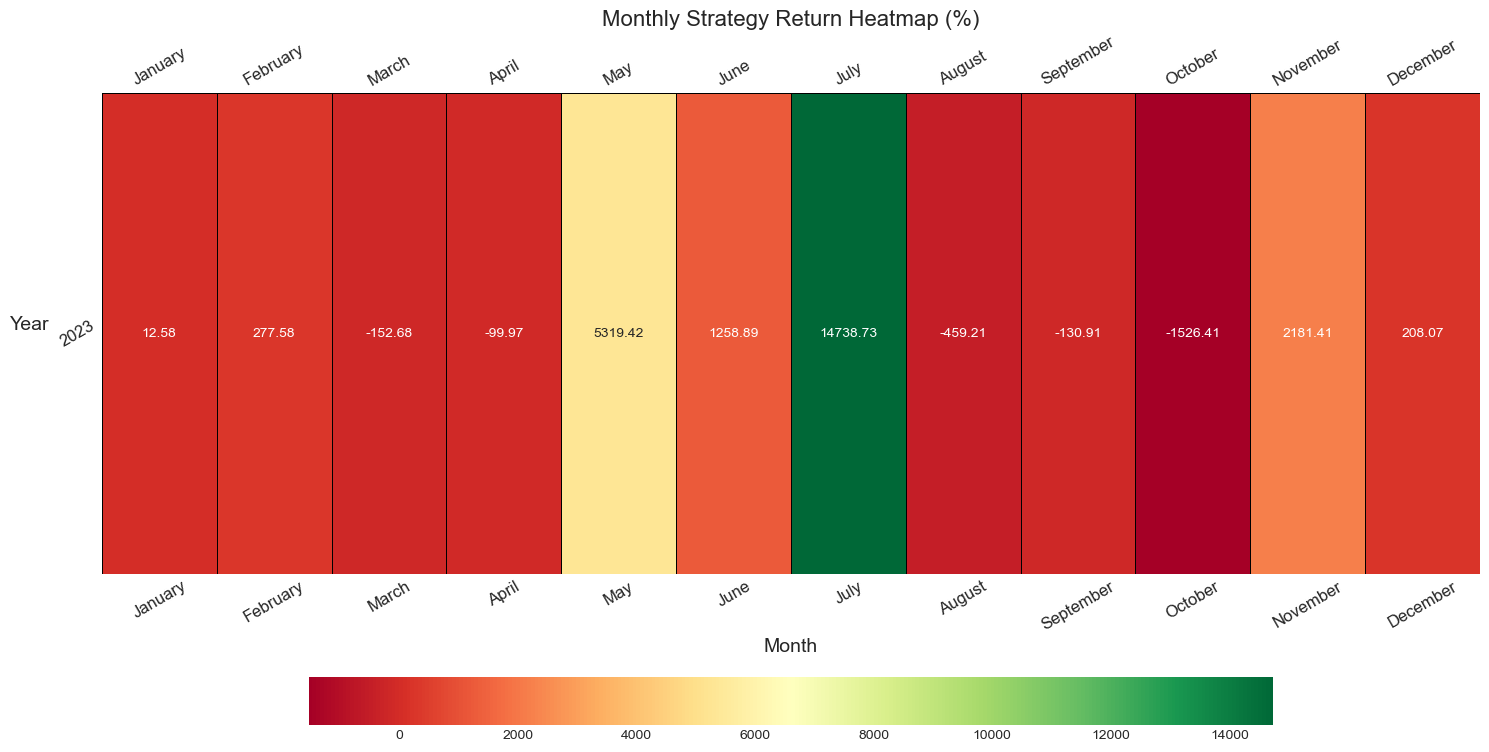

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Ensure datetime index
underlying_daily_data = underlying_daily_data.copy()
underlying_daily_data.index = pd.to_datetime(underlying_daily_data.index)

# Step 2: Compute monthly returns
monthly_returns = (
    (1 + underlying_daily_data['strategy_returns']).resample('M').prod() - 1
) * 100

# Step 3: Create DataFrame
heatmap_df = pd.DataFrame(monthly_returns)
heatmap_df.columns = ['monthly_return_pct']
heatmap_df['Year'] = heatmap_df.index.year
heatmap_df['Month'] = heatmap_df.index.month_name()

# Step 4: Pivot table
heatmap_pivot = heatmap_df.pivot(index='Year', columns='Month', values='monthly_return_pct')

# Reorder months
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
heatmap_pivot = heatmap_pivot.reindex(columns=month_order)

# Debug print
print("✅ Heatmap Pivot Table:\n", heatmap_pivot)

# Step 5: Plot heatmap
if not heatmap_pivot.empty and heatmap_pivot.notna().sum().sum() > 0:
    plt.figure(figsize=(15, 8))
    ax = sns.heatmap(
        heatmap_pivot,
        cmap='RdYlGn',
        annot=True,
        fmt='.2f',
        linewidths=0.5,
        linecolor='black',
        cbar_kws={"orientation": "horizontal", "shrink": 0.7}
    )

    ax.tick_params(top=True, labeltop=True, labelrotation=30, labelsize=12)
    ax.set_xlabel("Month", fontsize=14)
    ax.set_ylabel("Year", fontsize=14, rotation=0, labelpad=20)
    plt.title("Monthly Strategy Return Heatmap (%)", fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No valid monthly return data available to plot heatmap.")


### Maximum Drawdown Analysis

This section analyzes the **maximum drawdown** experienced by the strategy.

- **Objective**: Measure the largest decline in cumulative returns from a historical peak to a trough before a new peak is reached.
- **Process**:
  - Calculate the running maximum of cumulative returns.
  - Measure the percentage drop from the peak at each point.
  - Identify the maximum drawdown value and the period over which it occurred.
- **Visualization**:
  - Plot cumulative returns.
  - Highlight the drawdown area and mark the period of maximum drawdown.

This analysis helps evaluate the worst-case decline in portfolio value and is a key risk metric in performance evaluation.



📉 Maximum Drawdown: -99.90%
📆 From 2023-02-03 to 2023-03-08


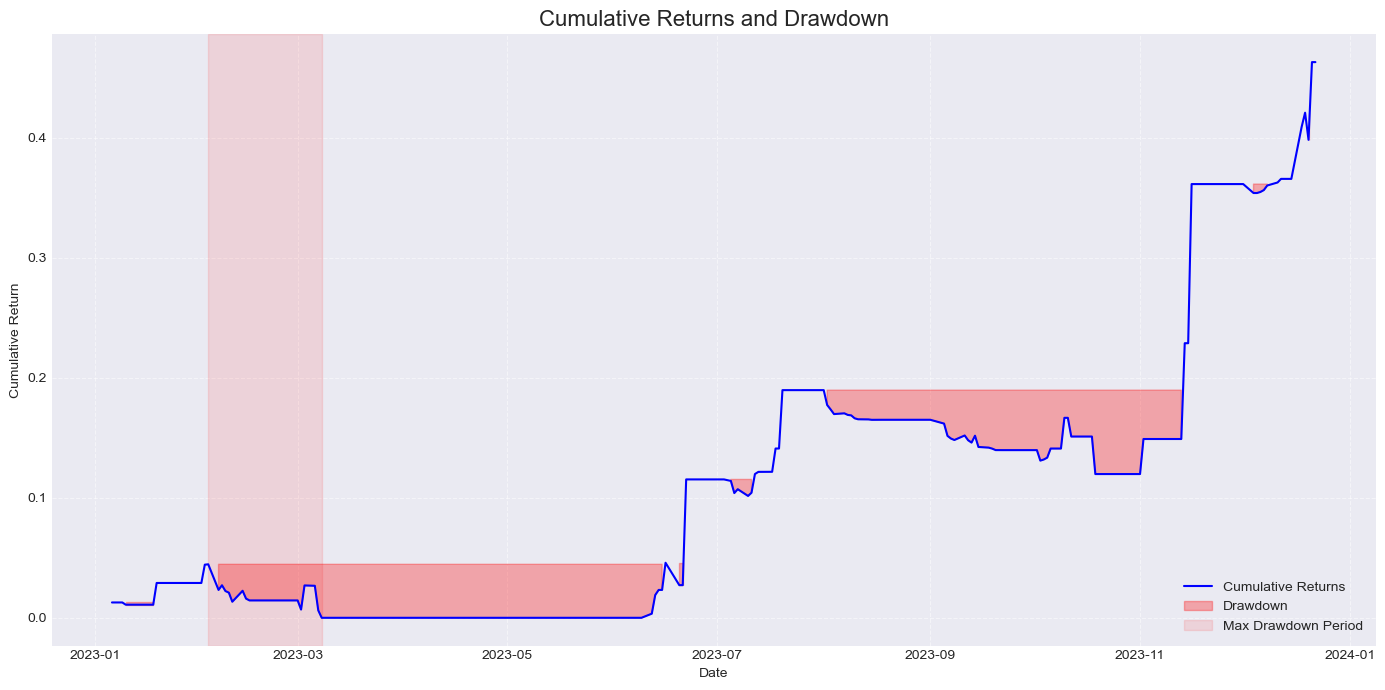

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Clean and prepare cumulative returns
cumulative_returns = underlying_daily_data['cumulative_returns'].copy()

# Replace 0 or negative cumulative returns with small epsilon to avoid divide-by-zero
cumulative_returns[cumulative_returns <= 0] = np.nan
cumulative_returns.fillna(method='ffill', inplace=True)  # forward-fill if gaps exist

# Step 2: Calculate running max
running_max = cumulative_returns.cummax()

# Step 3: Calculate drawdown
drawdown = (cumulative_returns - running_max) / running_max

# Step 4: Identify maximum drawdown
max_drawdown = drawdown.min()
end_date = drawdown.idxmin()
start_date = cumulative_returns.loc[:end_date].idxmax()

# Step 5: Display stats
print(f"\n📉 Maximum Drawdown: {max_drawdown:.2%}")
print(f"📆 From {start_date.date()} to {end_date.date()}")

# Step 6: Plot
plt.figure(figsize=(14, 7))
plt.plot(cumulative_returns, label='Cumulative Returns', color='blue')
plt.fill_between(drawdown.index, cumulative_returns, running_max,
                 where=(cumulative_returns < running_max),
                 color='red', alpha=0.3, label='Drawdown')
plt.axvspan(start_date, end_date, color='red', alpha=0.1, label='Max Drawdown Period')
plt.title("Cumulative Returns and Drawdown", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


⚠️ The observed maximum drawdown of ~99.9% is expected for a long call strategy, since the entire premium can be lost if the option expires worthless. This reflects the asymmetric payoff of long options, where downside is limited to the premium paid but losses can appear steep in percentage terms.

### Strategy Performance Metrics

In this section, we evaluate the performance of the strategy using three widely used quantitative metrics:

- **CAGR (Compounded Annual Growth Rate):**  
  Measures the annualized rate of return assuming the profits are reinvested. It helps assess how steadily the strategy has grown over time, regardless of volatility or intermediate drawdowns.

- **Annualised Volatility:**  
  Reflects the standard deviation of daily returns scaled to a yearly value. It captures the degree of variation in the strategy’s returns and serves as a proxy for risk.

- **Sharpe Ratio:**  
  Indicates the risk-adjusted return by comparing excess returns (over a risk-free rate) to volatility. A higher Sharpe ratio implies better return per unit of risk taken.

These metrics offer a compact and comprehensive view of both return and risk characteristics of the strategy.


In [22]:
# Total number of trading days
trading_days = len(underlying_daily_data)

# Calculate compounded annual growth rate
CAGR = (underlying_daily_data.cumulative_returns.iloc[-1]**(252/trading_days)-1)*100

print(f'The CAGR of the strategy is:', round(CAGR, 2), '%')


# Calculate annualised volatility
annualised_volatility = underlying_daily_data['strategy_returns'].std()*np.sqrt(252)

print(f'The annualised volatility of returns is',
      round(annualised_volatility, 1), '%')


# Set a risk-free rate
risk_free_rate = 0.02/252

# Calculate Sharpe ratio
sharpe_ratio = np.sqrt(252)*(np.mean(daily_mtm.daily_returns) -
                             (risk_free_rate))/np.std(daily_mtm.daily_returns)

print(f'The strategy has a Sharpe ratio of:', round(sharpe_ratio, 2))

The CAGR of the strategy is: -67.01 %
The annualised volatility of returns is 66.2 %
The strategy has a Sharpe ratio of: -3.32


⚠️ The negative CAGR (-67.01%) and Sharpe ratio (-3.32) indicate that the strategy has been consistently unprofitable during the backtest period. The high annualised volatility (66.2%) further highlights large fluctuations in returns. This is common in long call strategies when most options expire worthless, especially in the absence of strong directional moves or a robust signal.

### Adding Risk Management to the Strategy

This version of the backtest introduces **risk management through stop-loss and take-profit rules**, enhancing the previous approach where trades were only exited at expiry.

**Key Additions:**

- **Stop-Loss (SL):**  
  If the strategy experiences a loss greater than 20% of the premium paid (`-20%`), the position is exited immediately.

- **Take-Profit (TP):**  
  If the position gains more than 40% of the entry premium (`+40%`), the trade is closed to lock in profits.

- **Exit Hierarchy:**  
  - The stop-loss check is evaluated first, followed by the take-profit.  
  - If neither threshold is hit, the trade is exited on the day before expiry as usual.

This risk management logic provides better control over downside while systematically capturing upside opportunities, aligning the strategy with practical trading constraints.


## 

### Conclusion

In this notebook, we built a complete backtesting framework for a **Long Call options strategy**, incorporating both analytics and risk management. 

We began by simulating monthly long call trades based on entry and expiry rules. As part of our analysis, we computed **daily mark-to-market (MTM)** values and tracked key performance metrics like **CAGR**, **volatility**, **Sharpe ratio**, and **maximum drawdown**. We also visualized monthly returns using a heatmap to understand the seasonality and variability in performance.

Importantly, we extended the base strategy by integrating **systematic risk management** through stop-loss and take-profit rules. This addition helped us simulate more realistic trading behavior, limiting losses and locking in gains based on predefined thresholds.

Overall, this notebook not only demonstrates how to implement and backtest a directional options strategy, but also emphasizes the importance of **evaluating and managing risk** — a crucial component of any trading system.
